# Explore ArraySpec

Testing of methods for the ArraySpec C# object which is exposed to Python.

## Imports

In [1]:
from shellpower import ArraySimulator, ArraySimulatorInput, ArraySimulatorOutput
from shellpower.simulator.Simulation import Simulation
import datetime

## Instantiation

Use the luminos texture. Bypass diodes are needed as well, but may not be in the future.

In [2]:
aspec = Simulation.ArraySpec("./../arrays/luminos/luminos-splines-6-string-no-bypass-rot.png", "./../arrays/luminos/luminos.stl", "./bypass_diodes.json")

In [3]:
# List methods

def list_attrs(obj):
    # Methods/properties inherited from System.Object
    cs_object_members = {
        "Equals",
        "Finalize",
        "GetHashCode",
        "GetType",
        "MemberwiseClone",
        "ReferenceEquals",
        "ToString",
    }

    # Filter out:
    # - dunder names
    # - System.Object members
    # - pythonnet "Overloads"
    raw = dir(obj)
    filtered = [
        name for name in raw
        if not name.startswith("__")
        and name not in cs_object_members
        and name != "Overloads"
    ]

    return [(attr, type(getattr(obj, attr))) for attr in filtered]

list_attrs(aspec)

[('AddBypassDiode', CLR.MethodBinding),
 ('AddCellToCellString', CLR.MethodBinding),
 ('BypassDiode', clr._internal.CLRMetatype),
 ('BypassDiodeSpec', SSCP.ShellPower.DiodeSpec),
 ('Cell', clr._internal.CLRMetatype),
 ('CellSpec', SSCP.ShellPower.CellSpec),
 ('CellString', clr._internal.CLRMetatype),
 ('EncapsulationLoss', float),
 ('ExportBypass', CLR.MethodBinding),
 ('ImportBypassDiodes', CLR.MethodBinding),
 ('LayoutBounds', SSCP.ShellPower.BoundsSpec),
 ('LayoutTexture', SixLabors.ImageSharp.Image[Rgba32]),
 ('LoadMesh', CLR.MethodBinding),
 ('Mesh', SSCP.ShellPower.Mesh),
 ('ReadStringsFromColors', CLR.MethodBinding),
 ('Recolor', CLR.MethodBinding),
 ('RemoveBypassDiode', CLR.MethodBinding),
 ('SaveArrayTexture', CLR.MethodBinding),
 ('Strings', System.Collections.Generic.List[CellString]),
 ('get_BypassDiodeSpec', CLR.MethodBinding),
 ('get_CellSpec', CLR.MethodBinding),
 ('get_EncapsulationLoss', CLR.MethodBinding),
 ('get_LayoutBounds', CLR.MethodBinding),
 ('get_LayoutTextur

## Methods

Let's use a few of the methods to see how they work.

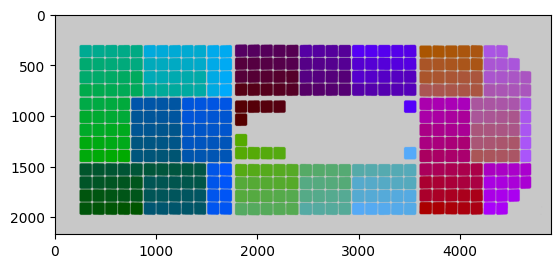

In [30]:
# Show the texture

texture_path = "./textures/test.png"

aspec.SaveArrayTexture(texture_path)

import matplotlib.pyplot as plt
from matplotlib import image as mpimg

image = mpimg.imread(texture_path)

plt.imshow(image)
plt.show()

In [5]:
aspec.get_CellSpec() == aspec.CellSpec # This getter is redundant

True

In [6]:
# Get Strings

strings = list(aspec.Strings)
strings

In [7]:
string_zero = strings[0]

list_attrs(string_zero)

[('BypassDiodes', System.Collections.Generic.List[BypassDiode]),
 ('Cells', System.Collections.Generic.List[Cell]),
 ('Name', str),
 ('get_BypassDiodes', CLR.MethodBinding),
 ('get_Cells', CLR.MethodBinding),
 ('get_Name', CLR.MethodBinding),
 ('set_Name', CLR.MethodBinding)]

In [8]:
# Get Cells

string_zero_cells = list(string_zero.Cells)
print(f"{len(string_zero_cells)} cells of type {type(string_zero_cells[0])}")

62 cells of type <class 'SSCP.ShellPower.Cell'>


In [9]:
list_attrs(string_zero_cells[0])

[('Color', SixLabors.ImageSharp.PixelFormats.Rgba32),
 ('Pixels', System.Collections.Generic.List[Pair[Int32]]),
 ('get_Color', CLR.MethodBinding),
 ('get_Pixels', CLR.MethodBinding),
 ('set_Color', CLR.MethodBinding)]

In [10]:
# Pixels: a list of coordinates

cell_pixels = list(string_zero_cells[0].Pixels)

for pix in cell_pixels[:5]:
    print(pix.First, pix.Second)
print('etc...')

1785 981
1786 981
1787 981
1788 981
1789 981
etc...


In [26]:
string_zero_cells[0].Color.ToString()

'Rgba32(85, 0, 0, 255)'

# Manipulating Cells

Now we know how to navigate and obtain a reference to any string or cell, and get the pixels and color of each cell.

Let's put it in practice by manipulating the colors.

In [12]:
for string in aspec.Strings:
    for cell in string.Cells:
        print(cell.Color.ToString())

Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 4, 255)
Rgba32(85, 0, 8, 255)
Rgba32(85, 0, 12, 255)
Rgba32(85, 0, 16, 255)
Rgba32(85, 0, 20, 255)
Rgba32(85, 0, 24, 255)
Rgba32(85, 0, 28, 255)
Rgba32(85, 0, 32, 255)
Rgba32(85, 0, 37, 255)
Rgba32(85, 0, 41, 255)
Rgba32(85, 0, 45, 255)
Rgba32(85, 0, 49, 255)
Rgba32(85, 0, 53, 255)
Rgba32(85, 0, 57, 255)
Rgba32(85, 0, 61, 255)
Rgba32(85, 0, 65, 255)
Rgba32(85, 0, 69, 255)
Rgba32(85, 0, 74, 255)
Rgba32(85, 0, 78, 255)
Rgba32(85, 0, 82, 255)
Rgba32(85, 0, 86, 255)
Rgba32(85, 0, 90, 255)
Rgba32(85, 0, 94, 255)
Rgba32(85, 0, 98, 255)
Rgba32(85, 0, 102, 255)
Rgba32(85, 0, 106, 255)
Rgba32(85, 0, 111, 255)
Rgba32(85, 0, 115, 255)
Rgba32(85, 0, 119, 255)
Rgba32(85, 0, 123, 255)
Rgba32(85, 0, 127, 255)
Rgba32(85, 0, 131, 255)
Rgba32(85, 0, 135, 255)
Rgba32(85, 0, 139, 255)
Rgba32(85, 0, 143, 255)
Rgba32(85, 0, 148, 255)
Rgba32(85, 0, 152, 255)
Rgba32(85, 0, 156, 255)
Rgba32(85, 0, 160, 255)
Rgba32(85, 0, 164, 255)
Rgba32(85, 0, 168, 255)
Rgba32(85, 0, 172, 2

In [13]:
# Make all cells the same color

first_cell_color = string_zero_cells[0].Color

for string in aspec.Strings:
    for cell in string.Cells:
        cell.set_Color(first_cell_color)

In [14]:
for string in aspec.Strings:
    for cell in string.Cells:
        print(cell.Color.ToString())

Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85, 0, 0, 255)
Rgba32(85,

Note: The texture image itself is not updated, so it we want to visualize the new arrayspec we will have to do this from scratch.

## Visualize Changes

Note: this takes about 10 seconds, as it iterates through pixels one-by-one.

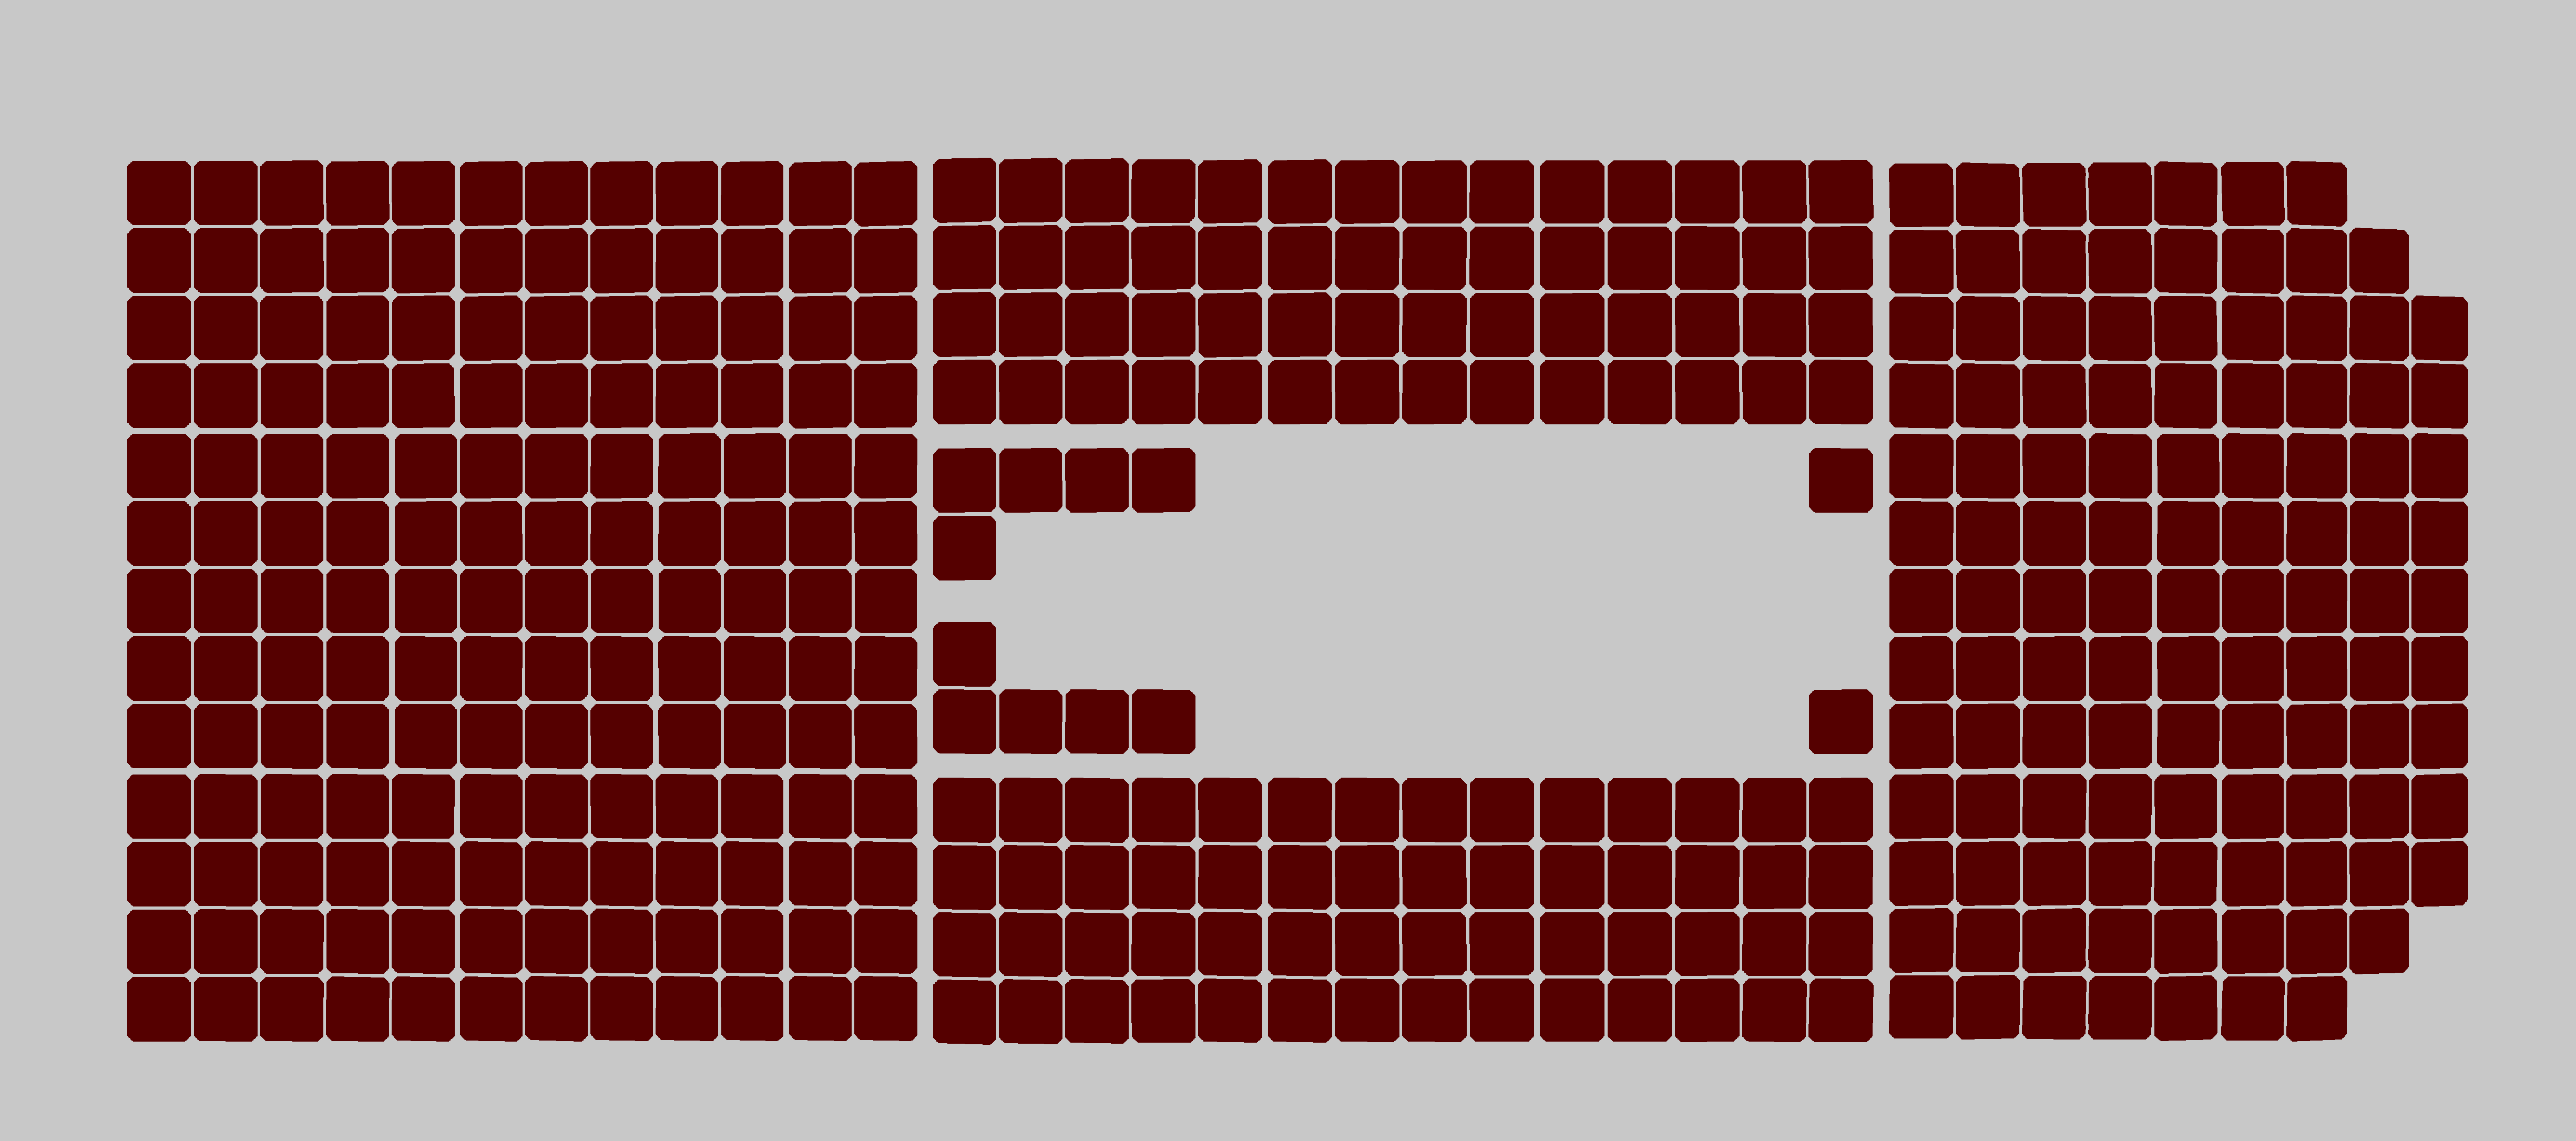

In [31]:
from PIL import Image

def get_new_texture(array_spec) -> Image:
    width = array_spec.LayoutTexture.Width
    height = array_spec.LayoutTexture.Height

    image = Image.new("RGB", (width, height), color=(200, 200, 200))

    # Step 2: Get access to the pixel data
    pixels = image.load()

    # Step 3: Set the pixel colors based on the pixel-color pairs
    for string in aspec.Strings:
        for cell in string.Cells:
            color = (cell.Color.R, cell.Color.G, cell.Color.B)
            for px in cell.Pixels:
                x = px.First
                y = px.Second
                if 0 <= x < width and 0 <= y < height:
                    pixels[x, y] = color

    return image


modified_texture = get_new_texture(aspec)
display(modified_texture)